In [1]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

In [3]:
train_dir = "/kaggle/input/coco-2017-dataset/coco2017/train2017"
val_dir = "/kaggle/input/coco-2017-dataset/coco2017/val2017"
test_dir = "/kaggle/input/coco-2017-dataset/coco2017/test2017"

In [4]:
print("Training Images:", len(os.listdir(train_dir)))
print("Validation Images:", len(os.listdir(val_dir)))
print("Test Images:", len(os.listdir(test_dir)))


Training Images: 118287
Validation Images: 5000
Test Images: 40670


In [5]:
images = os.listdir(train_dir)


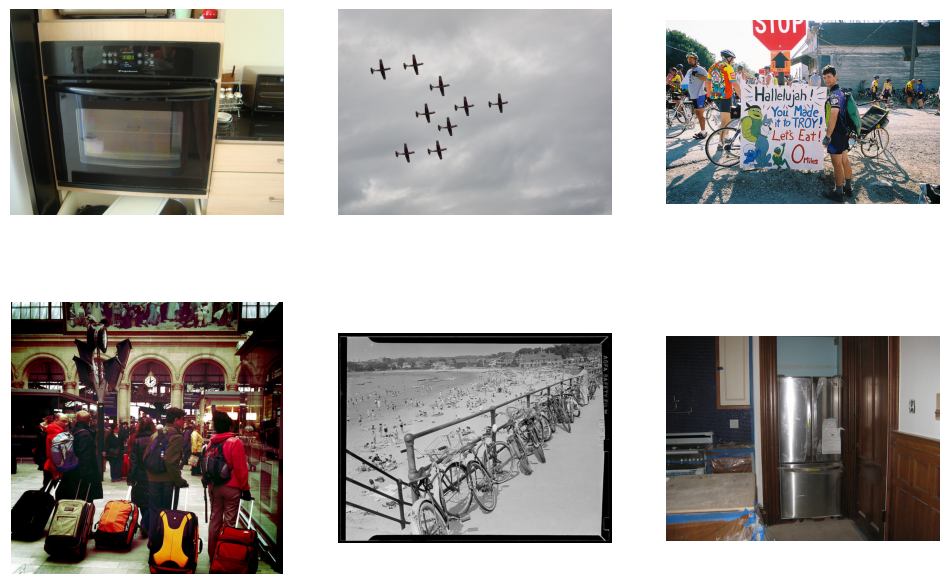

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(6):

    img_path = os.path.join(train_dir, images[i])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [7]:
IMG_SIZE = 128
TRAIN_LIMIT = 10000
VAL_LIMIT = 2000
TEST_LIMIT = 2000

In [8]:
def load_dataset(folder_path, limit):

    X = []
    Y = []

    image_files = os.listdir(folder_path)[:limit]

    for file in image_files:

        path = os.path.join(folder_path, file)

        image = cv2.imread(path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        image = image.astype(np.float32) / 255.0

        gray = cv2.cvtColor(
            (image * 255).astype(np.uint8),
            cv2.COLOR_RGB2GRAY
        )

        gray = gray.astype(np.float32) / 255.0

        gray = np.expand_dims(gray, axis=-1)

        X.append(gray)

        Y.append(image)

    return np.array(X), np.array(Y)

In [9]:
X_train, Y_train = load_dataset(
    train_dir,
    TRAIN_LIMIT
)

print("X_train Shape :", X_train.shape)
print("Y_train Shape :", Y_train.shape)

X_train Shape : (10000, 128, 128, 1)
Y_train Shape : (10000, 128, 128, 3)


In [10]:
X_val, Y_val = load_dataset(
    val_dir,
    VAL_LIMIT
)

print("X_val Shape :", X_val.shape)
print("Y_val Shape :", Y_val.shape)

X_val Shape : (2000, 128, 128, 1)
Y_val Shape : (2000, 128, 128, 3)


In [11]:
X_test, Y_test = load_dataset(
    test_dir,
    TEST_LIMIT
)

print("X_test Shape :", X_test.shape)
print("Y_test Shape :", Y_test.shape)

X_test Shape : (2000, 128, 128, 1)
Y_test Shape : (2000, 128, 128, 3)


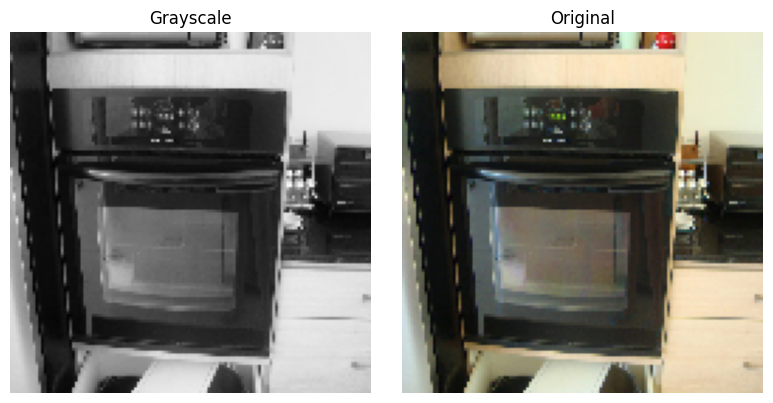

In [13]:
plt.figure(figsize=(8,4))

# Grayscale Image
plt.subplot(1,2,1)
plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Original Color Image
plt.subplot(1,2,2)
plt.imshow(Y_train[0])
plt.title("Original")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D , Dropout , BatchNormalization

In [15]:
input_img = Input(shape=(128, 128, 1))

# ---------------- Encoder ----------------

x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck
x = Conv2D(512, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# ---------------- Decoder ----------------

x = UpSampling2D((2,2))(x)
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

output = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

model = Model(input_img, output)

In [16]:

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 64)   │           25

 Total params: 3,105,923 (11.85 MB)

 Trainable params: 3,103,107 (11.84 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [17]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [18]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=16,
    shuffle=True
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 102ms/step - loss: 0.0204 - mae: 0.1029 - val_loss: 0.0171 - val_mae: 0.0975
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - loss: 0.0162 - mae: 0.0914 - val_loss: 0.0142 - val_mae: 0.0820
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - loss: 0.0151 - mae: 0.0877 - val_loss: 0.0156 - val_mae: 0.0915
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - loss: 0.0144 - mae: 0.0853 - val_loss: 0.0138 - val_mae: 0.0818
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - loss: 0.0139 - mae: 0.0837 - val_loss: 0.0134 - val_mae: 0.0811
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - loss: 0.0135 - mae: 0.0827 - val_loss: 0.0128 - val_mae: 0.0772
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - loss: 0.0133 - mae: 0.0817 - val_loss: 0.0125 - val_mae: 0.0775
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - loss: 0.0132 - mae: 0.0813 - val_loss: 0.0215 - val_mae: 0.1115
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━

In [19]:
loss, mae = model.evaluate(X_test, Y_test)

print("Test Loss :", loss)
print("Test MAE :", mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0102 - mae: 0.0679
Test Loss : 0.01015985943377018
Test MAE : 0.06792809069156647


In [20]:
predictions = model.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


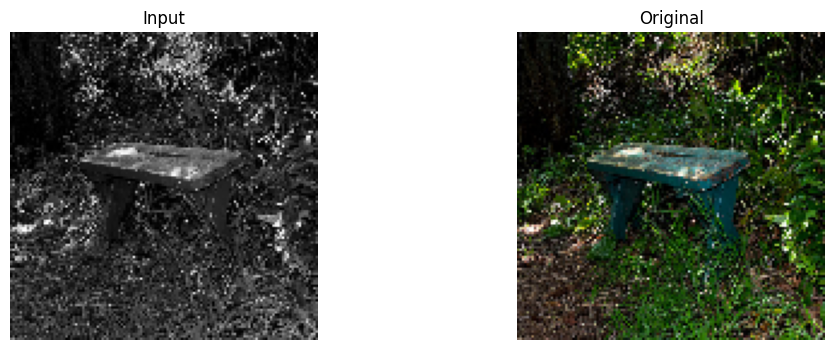

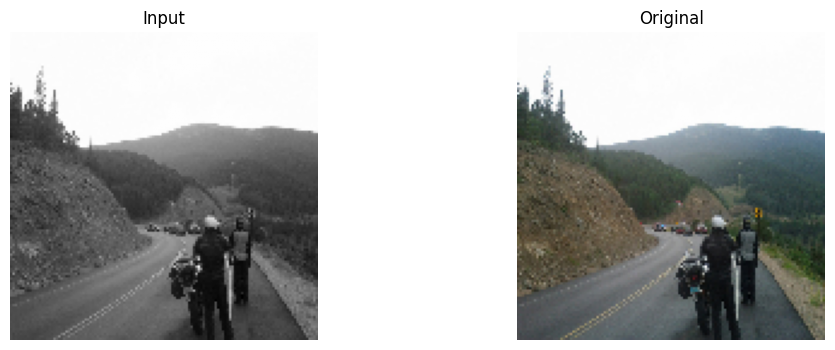

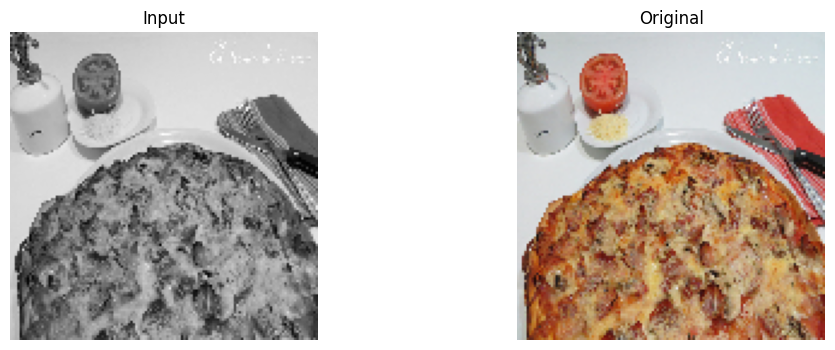

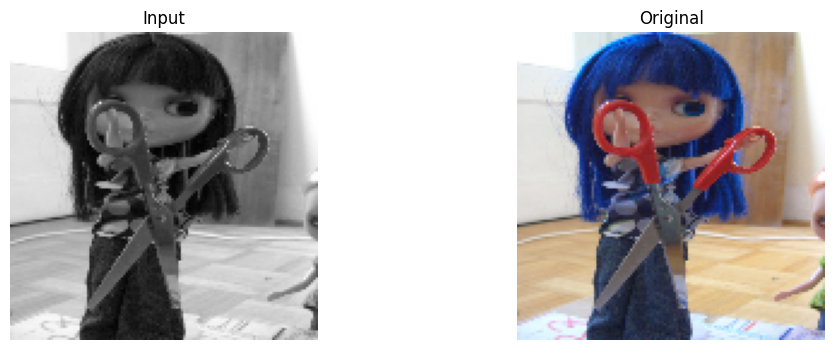

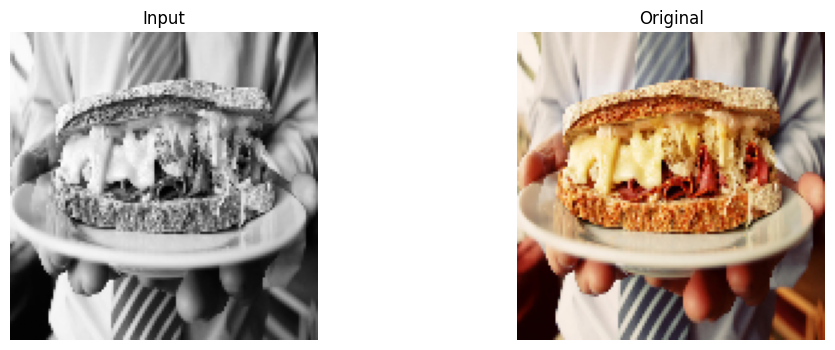

In [30]:
for i in range(5):

    plt.figure(figsize=(12,4))

    # Grayscale Input
    plt.subplot(1,2,1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Input")
    plt.axis("off")

    # Original Color
    plt.subplot(1,2,2)
    plt.imshow(Y_test[i])
    plt.title("Original")
    plt.axis("off")

    plt.show()

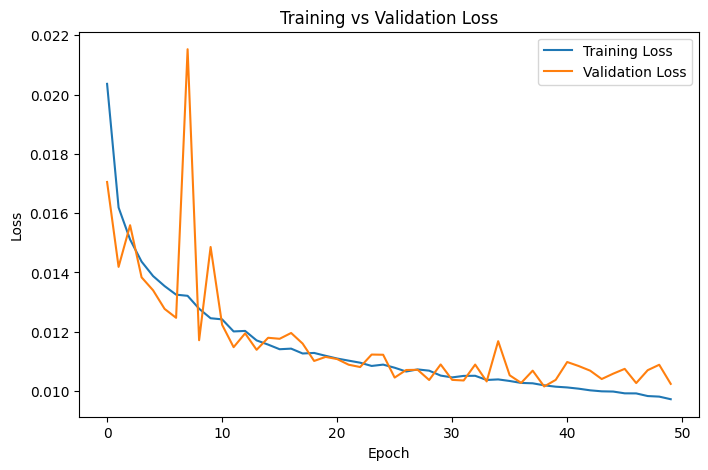

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

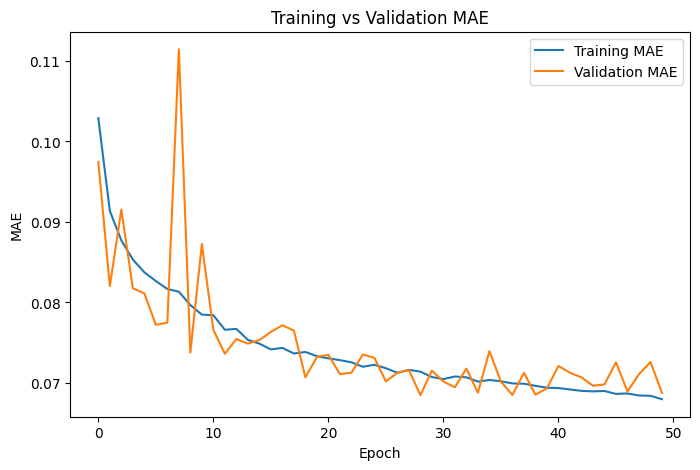

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


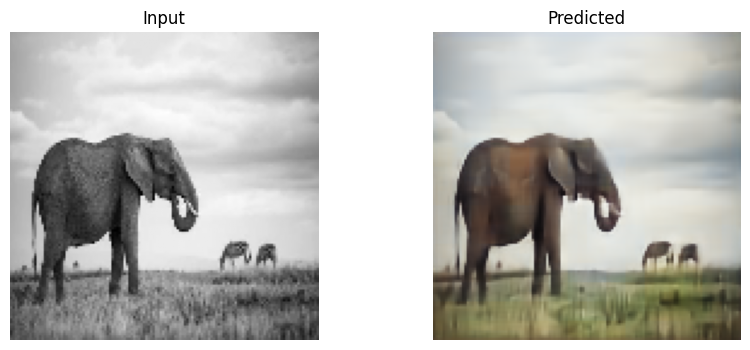

In [32]:
# Test on new images
img = cv2.imread("/content/test_img.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (128,128))

img = img.astype(np.float32)/255.0

gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = gray.astype(np.float32)/255.0
gray = np.expand_dims(gray, axis=-1)
gray = np.expand_dims(gray, axis=0)

pred = model.predict(gray)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray[0].squeeze(), cmap='gray')
plt.title("Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred[0])
plt.title("Predicted")
plt.axis("off")

plt.show()

In [29]:
model.save("colorization_autoencoder.keras")